Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training on 510 sentences...
Epoch [0/79], Loss: 1.8958
Epoch [10/79], Loss: 1.4823
Epoch [20/79], Loss: 1.2200
Epoch [30/79], Loss: 0.9160
Epoch [40/79], Loss: 0.5599
Epoch [50/79], Loss: 0.2797
Epoch [60/79], Loss: 0.1267
Epoch [70/79], Loss: 0.0569
Epoch [79/79], Loss: 0.0226


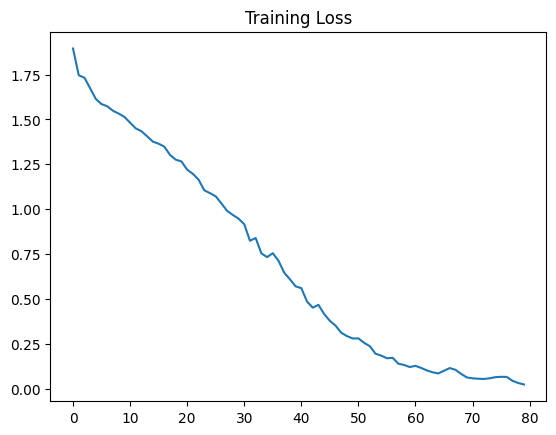

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sentence_transformers import SentenceTransformer
import numpy as np
import random
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
LR = 1e-3
BATCH_SIZE = 16
MAX_LEN = 20

class PointerAttention(nn.Module):# Bi-LSTM Pointer Network
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        # encoder_outputs: [batch, seq_len, hidden_dim]
        # decoder_hidden: [batch, hidden_dim]
        out = torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1))
        scores = self.vt(out).squeeze(2)
        return scores

class PointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attention = PointerAttention(hidden_dim)


        self.reduce_h = nn.Linear(hidden_dim * 2, hidden_dim) # Project Bi-LSTM (2 * hidden) back to decoder size (hidden)
        self.reduce_c = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        enc_out, (h_n, c_n) = self.encoder(x)

        # Prepare initial decoder state
        h_d = self.reduce_h(torch.cat((h_n[0], h_n[1]), dim=1)).unsqueeze(0)
        c_d = self.reduce_c(torch.cat((c_n[0], c_n[1]), dim=1)).unsqueeze(0)

        # Sum bidirectional outputs for attention key
        enc_out_reduced = enc_out[:, :, :HIDDEN_DIM] + enc_out[:, :, HIDDEN_DIM:]

        all_logits = []
        decoder_input = torch.zeros(batch_size, 1, HIDDEN_DIM).to(DEVICE)

        for _ in range(seq_len):
            _, (h_d, c_d) = self.decoder(decoder_input, (h_d, c_d))
            logits = self.attention(h_d.squeeze(0), enc_out_reduced)
            all_logits.append(logits)

        return torch.stack(all_logits, dim=1) # [batch, seq_len, seq_len]

all_files = [
    "/content/ArSL-tr01-glossed+Processed.txt",
    #"/content/ArSL-tr02-glossed+Processed.txt",
    "/content/ArSL-val01-glossed+Processed.txt"
    #"/content/ArSL-val02-glossed+Processed.txt"
]

combined_lines = []
for f_path in all_files:
    try:
        with open(f_path, 'r', encoding="utf-8") as f:
            combined_lines.extend([l.strip() for l in f if l.strip()])
    except FileNotFoundError:
        print(f"File missing: {f_path}")

class MegaDataset(Dataset):
    def __init__(self, lines, augment=True):
        self.lines = list(set(lines)) # De-duplicate
        self.augment = augment

    def __len__(self): return len(self.lines)

    def __getitem__(self, idx):
        line_words = self.lines[idx].split()[:MAX_LEN]
        target_words = list(line_words)
        source_words = list(line_words)

        if self.augment:
            random.shuffle(source_words)

        target_indices = []
        for word in target_words:
            if word in source_words:
                target_indices.append(source_words.index(word))
            else:
                target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 384))
        padded_embeds[:len(source_words)] = embeddings

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices

        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words)

def train_ptr_net(train_loader, num_epochs=80):
    model = PointerNet(384, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_history = []

    print(f"Training on {len(combined_lines)} sentences")
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch}/{num_epochs-1}], Loss: {avg_loss:.4f}")

    plt.plot(loss_history)
    plt.title("Training Loss")
    plt.show()
    return model

def reorder_sentence_hybrid(model, sentence):
    particles = ["قبل" ,"اثنان" ,"كثير" ,"في", "و", "على", "من", "إلى", "عن", "ثم"]
    words = sentence.split()
    glued = []
    i = 0
    while i < len(words):
        if words[i] in particles and i + 1 < len(words):
            glued.append(f"{words[i]}_{words[i+1]}")
            i += 2
        else:
            glued.append(words[i])
            i += 1

    clean_glued = [w.replace("؟", "").replace("!", "") for w in glued]
    n = len(clean_glued)

    model.eval()
    with torch.no_grad():
        emb = torch.FloatTensor(EMBED_MODEL.encode(clean_glued)).unsqueeze(0).to(DEVICE)
        padded_x = torch.zeros(1, MAX_LEN, 384).to(DEVICE)
        padded_x[0, :n] = emb
        logits = model(padded_x)[0]

        indices = []
        mask = torch.zeros(n).to(DEVICE)
        for step in range(n):
            step_logits = logits[step, :n] + mask
            idx = torch.argmax(step_logits).item()
            indices.append(idx)
            mask[idx] = -1e9

        reordered = [clean_glued[idx] for idx in indices]

    final = " ".join(reordered).replace("_", " ")

    if "؟" in sentence:
        final = "؟ " + final

    return final

mega_ds = MegaDataset(combined_lines, augment=True)
loader = DataLoader(mega_ds, batch_size=BATCH_SIZE, shuffle=True)

model = train_ptr_net(loader, num_epochs=80)


In [14]:
torch.save(model.state_dict(), "pointer_net_arsl.pth")

print(reorder_sentence_hybrid(model, "أين غرفة المعيشة؟"))

؟ غرفة المعيشة أين


In [15]:
print(reorder_sentence_hybrid(model, "فنجان قهوة"))

فنجان قهوة
